In [1]:
import os
import sys
import torch
import torchvision

from torch import optim
# from torchvision.transforms import GaussianBlur, Resize

from optical_volume import optics, scene, utils
# from py_wave_propagator import torch_volume_prop as propagator

from matplotlib import pyplot as plt

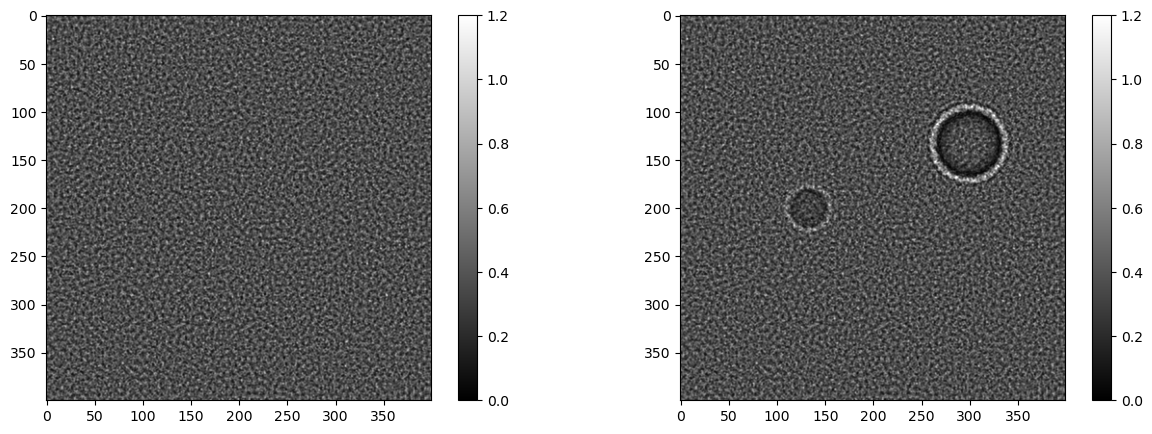

In [2]:
# example: functioning
WL = 500e-9
OBJ_SPACING = [100e-9, 100e-9, 100e-9]
SHAPE = [600, 600, 100]
NA = 0.7
DIST_PM_IM = 1.43e-3

TILE_LEN = 12e-6
PM_HEIGHT = 100e-9
PM_RI = 1.46
PM_SIG = 0.6

N_BG = 1.51
PAD = 512
FOC_PLANE_VAR = 0.1e-8

MAG = 40
OBJ_IMG_FACTOR = 20
EFF_MAG = int(40/20)

IMG_SPACING = [OBJ_SPACING[i]*OBJ_IMG_FACTOR for i in range(2)]
DIGITAL_PX = 6e-6
SUM_PATCH = int(DIGITAL_PX/IMG_SPACING[0])

DEVICE = 'cuda:1'


sphere1 = scene.shapes.Sphere(torch.tensor((20e-6, 45e-6, 3e-6)).float(), torch.tensor((5e-6)), torch.tensor(1.46), softness=1e-12)
sphere2 = scene.shapes.Sphere(torch.tensor((30e-6, 20e-6, 5e-6)).float(), torch.tensor((3e-6)), torch.tensor(1.46), softness=1e-12)
    
vol = scene.CollectionVolume(SHAPE, OBJ_SPACING, N_BG)
vol.add([sphere1, sphere2])

vol_prop = optics.VolumePropagator(WL, OBJ_SPACING, N_BG)

# plt.imshow(vol.forward()[:, :, 50].detach())
# plt.colorbar()
# plt.show()

lens = optics.F4ImagingSystem(WL, OBJ_SPACING, SHAPE, NA)
mag_obj = optics.utils.Magnification(torch.tensor(MAG/OBJ_IMG_FACTOR))
pm_obj = optics.BinaryPhaseMask(WL, TILE_LEN, IMG_SPACING, [x*EFF_MAG for x in SHAPE], PM_HEIGHT, PM_SIG, PM_RI)
px_int_obj = optics.utils.PixelIntegrator(SUM_PATCH)

# tile_size_px = torch.ceil(torch.tensor(TILE_LEN/SPACING[0])).int() # 25, sqaure cells in voxels
# num_tiles_x, num_tiles_y = torch.ceil(SHAPE[0]/tile_size_px).int(), torch.ceil(SHAPE[1]/tile_size_px).int() # 16x16, number of tiles
# pm_obj = optics.CustomPhaseMask(WL, TILE_LEN, SPACING, SHAPE, torch.rand(num_tiles_x, num_tiles_y).float()*1e-6, PM_SIG, PM_RI)

prop_obj_space = optics.FreeSpacePropagator(WL/N_BG, OBJ_SPACING[:2], SHAPE[2]*OBJ_SPACING[2]/2 - FOC_PLANE_VAR, direction='backward', padding=PAD)
prop_img_space = optics.FreeSpacePropagator(WL, IMG_SPACING, DIST_PM_IM, direction='backward', padding=PAD)

cwfs_basic = optics.system.OpticalSystem((
        prop_obj_space, # centring + displacing focus plalne
        lens, # imaging the wavefield
        mag_obj, # magnified by MAG/OBJ_IMG_FACTOR
        prop_img_space, # prop to mask plane
        pm_obj, # applying the mask
        prop_img_space.set_direction('forward'), # prop to image plane
        px_int_obj # add complex values incident on each pixel patch
    ))

vol.to(DEVICE)
cwfs_basic.to(DEVICE)

exit_field = vol_prop.forward(vol.forward())

ref_field = cwfs_basic(torch.ones(SHAPE[:2]).type(torch.complex64).to(DEVICE))
cwfs_basic.fields.clear()
spn_field = cwfs_basic(exit_field.type(torch.complex64))

img_ref = ref_field.abs().detach().to('cpu')**2
img_spn = spn_field.abs().detach().to('cpu')**2

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(img_ref/img_ref.max(), cmap='gray', vmin=0, vmax=1.2)
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(img_spn/img_ref.max(), cmap='gray', vmin=0, vmax=1.2)
plt.colorbar(cm1, ax=axs[1])

plt.show()

In [3]:
display(cwfs_basic.state_dict())
print('------------------')
for params in cwfs_basic.parameters():
    display(params)

OrderedDict([('elements.0.distance', tensor(4.9990e-06, device='cuda:1')),
             ('elements.1.NA', tensor(0.7000, device='cuda:1')),
             ('elements.1.pupil_amp',
              tensor([[1., 1., 1.,  ..., 1., 1., 1.],
                      [1., 1., 1.,  ..., 1., 1., 1.],
                      [1., 1., 1.,  ..., 1., 1., 1.],
                      ...,
                      [1., 1., 1.,  ..., 1., 1., 1.],
                      [1., 1., 1.,  ..., 1., 1., 1.],
                      [1., 1., 1.,  ..., 1., 1., 1.]], device='cuda:1')),
             ('elements.1.pupil_opd',
              tensor([[0., 0., 0.,  ..., 0., 0., 0.],
                      [0., 0., 0.,  ..., 0., 0., 0.],
                      [0., 0., 0.,  ..., 0., 0., 0.],
                      ...,
                      [0., 0., 0.,  ..., 0., 0., 0.],
                      [0., 0., 0.,  ..., 0., 0., 0.],
                      [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:1')),
             ('elements.3.distance', tenso

------------------


Parameter containing:
tensor(4.9990e-06, device='cuda:1', requires_grad=True)

Parameter containing:
tensor(0.7000, device='cuda:1', requires_grad=True)

Parameter containing:
tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]], device='cuda:1', requires_grad=True)

Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:1', requires_grad=True)

Parameter containing:
tensor(0.0014, device='cuda:1', requires_grad=True)

Parameter containing:
tensor(1.0000e-07, device='cuda:1', requires_grad=True)

Parameter containing:
tensor(-0.5108, device='cuda:1', requires_grad=True)

Parameter containing:
tensor([[[[1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j]]]], device='cuda:1')

In [4]:
display(vol.state_dict())
print('------------------')
for params in vol.parameters():
    display(params)

OrderedDict([('X',
              tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
                        0.0000e+00, 0.0000e+00],
                       [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
                        0.0000e+00, 0.0000e+00],
                       [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
                        0.0000e+00, 0.0000e+00],
                       ...,
                       [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
                        0.0000e+00, 0.0000e+00],
                       [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
                        0.0000e+00, 0.0000e+00],
                       [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
                        0.0000e+00, 0.0000e+00]],
              
                      [[1.0000e-07, 1.0000e-07, 1.0000e-07,  ..., 1.0000e-07,
                        1.0000e-07, 1.0000e-07],
                       [1.0000e-07, 1.0000e-07, 

------------------


Parameter containing:
tensor([2.0000e-05, 4.5000e-05, 3.0000e-06], device='cuda:1',
       requires_grad=True)

Parameter containing:
tensor(5.0000e-06, device='cuda:1', requires_grad=True)

Parameter containing:
tensor(1.4600, device='cuda:1', requires_grad=True)

Parameter containing:
tensor([3.0000e-05, 2.0000e-05, 5.0000e-06], device='cuda:1',
       requires_grad=True)

Parameter containing:
tensor(3.0000e-06, device='cuda:1', requires_grad=True)

Parameter containing:
tensor(1.4600, device='cuda:1', requires_grad=True)

In [5]:
# optimizer = optim.Adam(list(vol.parameters()) + list(cwfs_basic.parameters()), lr=1e-3)

optimizer = optim.Adam([
    {"params": vol.parameters(), "lr": 1e-2},
    {"params": [cwfs_basic.elements[3].distance, cwfs_basic.elements[4].height], "lr": 1e-3}
])

In [7]:
vol.to('cpu'), cwfs_basic.to('cpu')

(CollectionVolume(
   (shapes): ModuleList(
     (0-1): 2 x Sphere()
   )
 ),
 OpticalSystem(
   (elements): ModuleList(
     (0): FreeSpacePropagator(
       (PAD): Pad(padding=512, fill=0, padding_mode=edge)
     )
     (1): F4ImagingSystem()
     (2): Magnification()
     (3): FreeSpacePropagator(
       (PAD): Pad(padding=512, fill=0, padding_mode=edge)
     )
     (4): BinaryPhaseMask()
     (5): FreeSpacePropagator(
       (PAD): Pad(padding=512, fill=0, padding_mode=edge)
     )
     (6): PixelIntegrator(
       (conv2d): Conv2d(1, 1, kernel_size=(3, 3), stride=(3, 3), bias=False)
     )
   )
 ))